In [1]:

%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.io import savemat

from wrf_io import *

from itertools import product

from MITRotor import IEA10MW

import seaborn as sns

In [3]:
save_path = '/scratch/09909/smata/induction_modeling/gaussian_process/10MW/train_data/'

In [4]:
casenames = [
r'sn030_vn200',
r'sn030_vn100',
r'sn030_vn050',
r'sn030_vn025',
r'sn030_v000',
r'sn030_v025',
r'sn030_v050',
r'sn030_v100',
r'sn030_v200',
r'sn020_vn200',
r'sn020_vn100',
r'sn020_vn050',
r'sn020_vn025',
r'sn020_v000',
r'sn020_v025',
r'sn020_v050',
r'sn020_v100',
r'sn020_v200',
r'sn010_vn200',
r'sn010_vn100',
r'sn010_vn050',
r'sn010_vn025',
r'sn010_v000',
r'sn010_v025',
r'sn010_v050',
r'sn010_v100',
r'sn010_v200',
r's000_vn200',
r's000_vn100',
r's000_vn050',
r's000_vn025',
r's000_v000',
r's000_v025',
r's000_v050',
r's000_v100',
r's000_v200',
r's010_vn200',
r's010_vn100',
r's010_vn050',
r's010_vn025',
r's010_v000',
r's010_v025',
r's010_v050',
r's010_v100',
r's010_v200',
r's020_vn200',
r's020_vn100',
r's020_vn050',
r's020_vn025',
r's020_v000',
r's020_v025',
r's020_v050',
r's020_v100',
r's020_v200',
r's030_vn200',
r's030_vn100',
r's030_vn050',
r's030_vn025',
r's030_v000',
r's030_v025',
r's030_v050',
r's030_v100',
r's030_v200'
]

In [5]:
par_path = '/scratch/09909/smata/wrf_les_sweep/runs/10MW/rate/gad_sweep/parameters.pkl'

params = postproc.load_params(par_path)
data   = postproc.extract_sounding(params=params, local=False)
wrfles = postproc.load_data(params=params, casenames=casenames, local=False)

allocation     : ATM170028
partition      : spr
runtime        : 48:00:00
system         : stampede
num_nodes      : 2
exclude_time   : 10
save_interval  : 10
base_dir       : /scratch/09909/smata/wrf_les_sweep/runs/10MW/rate
wrf_path       : /work2/09909/smata/stampede3/WRF_LES
template_path  : /scratch/09909/smata/wrf_les_sweep/templates
turb_model     : iea10MW
rotor_model    : GAD
slice_loc      : 1
print_table    : True
plot_outer     : True
save_outer     : False
outer_align    : False
plot_inner     : True
save_inner     : False
save_both      : False
outer_pad      : 75
plot_profiles  : True
save_profiles  : True
batch_submit   : True
prof_type      : Idealized
shear_type     : Rate
shear          : [-0.03, -0.02, -0.01, 0, 0.01, 0.02, 0.03]
veer           : [-0.2, -0.1, -0.05, -0.025, 0, 0.025, 0.05, 0.1, 0.2]
excluded_pairs : []
Ufst           : 7


In [6]:
fontsize = 24
plt.rcParams['xtick.labelsize'] = 20 
plt.rcParams['ytick.labelsize'] = 20 

plt.rcParams.update({
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

In [7]:
cases = [pair for pair in product(params['shear'], params['veer'])]
shears = [pair[0] for pair in cases]
veers = [pair[1] for pair in cases]

In [8]:
Nelm = wrfles[0]['Nelm']
Nsct = wrfles[0]['Nsct']

t = np.linspace(0,2*np.pi,Nsct)
r = np.linspace(0,1,Nelm)

rho = 1.225

z_hh = wrfles[0]['hub_height']

R, T = np.meshgrid(r, t)

X = R * np.sin(T)
Y = (R * np.cos(T)) * wrfles[0]['radius'] + z_hh

wrf_vax      = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_vtn      = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_vax_real = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_vtn_real = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_vtn_NR   = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_vtn_NR_real= np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_W        = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_W_real   = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_CL       = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_CD       = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_CL_real  = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_CD_real  = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_L        = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_D        = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_L_real   = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_D_real   = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_FN       = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_FT       = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_FN_real  = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_FT_real  = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_phi      = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_phi_real = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_aoa      = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_aoa_real = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_cax      = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_pow      = np.zeros(len(casenames),dtype='longdouble')
wrf_thr      = np.zeros(len(casenames),dtype='longdouble')

wrf_pow_real = np.zeros(len(casenames),dtype='longdouble')
wrf_thr_real = np.zeros(len(casenames),dtype='longdouble')

shapiro      = np.zeros(len(casenames), dtype=float)

Uhub         = np.zeros(len(casenames), dtype=float)

wrf_tsr      = np.zeros(len(casenames), dtype=float)
wrf_omg      = np.zeros(len(casenames), dtype=float)

wrf_cot_rot  = np.zeros(len(casenames), dtype=float)
wrf_ind_rot  = np.zeros(len(casenames), dtype=float)

r_ann        = np.zeros((Nelm, len(casenames)),dtype='longdouble')
shears_ann   = np.zeros((Nelm, len(casenames)),dtype='longdouble')
veers_ann    = np.zeros((Nelm, len(casenames)),dtype='longdouble')

wrf_cot_ann  = np.zeros((Nelm, len(casenames)),dtype='longdouble')
wrf_ind_ann  = np.zeros((Nelm, len(casenames)),dtype='longdouble')

wrf_cot_loc  = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_ind_loc  = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

rotor = IEA10MW()

for count,case in enumerate(casenames):

    # Rotor radius
    R = wrfles[count]['radius']

    # Extract background flow
    u_func = interp1d(data[case][:,0], data[case][:,1], kind='linear')
    v_func = interp1d(data[case][:,0], data[case][:,2], kind='linear')

    # u and v velocity functions
    u_inf = u_func(Y)
    v_inf = v_func(Y)

    # Extract u and v velocity components at the rotor disk
    # u_rotor = np.mean(wrfles[count]['shapiroM'][0] * wrfles[count]['u'],axis=0)
    u_rotor = np.mean(wrfles[count]['u'],axis=0)
    v_rotor = np.mean(wrfles[count]['v'],axis=0)
    w_rotor = np.mean(wrfles[count]['w'],axis=0)

    # Magnitude of wind speed at rotor disk
    U = np.sqrt(u_rotor**2 + v_rotor**2)

    # Local wind misalignment angle at the rotor disk
    wdir = np.atan2(v_rotor,u_rotor)

    # Nondimensional radial positions
    r = wrfles[count]['rOverR']
    r_mat =  (np.ones_like(wdir.T) * r).T

    # Azimuthal coordinates
    theta = np.linspace(0, 2*np.pi, wrfles[count]['Nsct'])

    # Freestream wind speed at hub height
    U_hub = np.sqrt(u_func(z_hh)**2 + v_func(z_hh)**2)

    # Radial chord lengths
    chord = rotor.chord_func(r)
    chord =  (np.ones_like(wdir.T) * chord).T

    # Radial twist
    twist = rotor.twist_func(r)
    
    # Local solidity
    sigma_r = 3 * chord / (2 * np.pi * r_mat * R)

    # Local solidity
    sigma = 3/Nsct

    # Tip speed ratio
    omega = np.mean(wrfles[count]['omega'], axis=0) * 2 * np.pi / 60
    tsr = np.mean(omega*R/(U_hub), axis=0) 

    trbYaw = np.mean(wrfles[count]['yaw'], axis=0) 

    Vax, Vtn_NR, _ = postproc.rotGlobalToLocal(Nelm,Nsct,u_rotor,v_rotor,np.zeros_like(u_rotor))

    Vtn = omega * r_mat * R - Vtn_NR

    # Relative velocity
    W = np.sqrt(Vax**2 + Vtn**2)

    # Inflow angle
    phi = np.atan2(Vax,Vtn)

    aoa  = phi - twist[:, np.newaxis]
    Cl, Cd = rotor.clcd(r_mat, aoa)

    # Axial coefficient
    Cax = Cl * np.cos(phi) + Cd * np.sin(phi)

    # Local CT
    ct = sigma_r * (W/U_hub)**2 * Cax

    L = 1/2 * rho * chord * (Cl * W**2)
    D = 1/2 * rho * chord * (Cd * W**2)

    FN = L * np.cos(phi) + D * np.sin(phi)
    FT = L * np.sin(phi) - D * np.cos(phi)

    dr = (R - rotor.hub_radius)/Nelm

    T = np.sum(FN * dr * sigma)
    P = np.sum(FT * r_mat * R * dr * sigma * omega)

    wrf_vax[:,:,count]      = Vax
    wrf_vtn[:,:,count]      = Vtn

    wrf_vax_real[:,:,count] = np.mean(wrfles[count]['v1'], axis=0)
    wrf_vtn_real[:,:,count] = np.mean(wrfles[count]['v_tan'], axis=0)
  
    wrf_vtn_NR[:,:,count]   = Vtn_NR
    wrf_vtn_NR_real[:,:,count] = np.mean(wrfles[count]['v_tan_no_rot'], axis=0)

    wrf_phi[:,:,count]      = phi
    wrf_phi_real[:,:,count] = np.deg2rad(np.mean(wrfles[count]['phi'], axis=0))

    wrf_aoa[:,:,count]      = aoa
    wrf_aoa_real[:,:,count] = np.deg2rad(np.mean(wrfles[count]['aoa'], axis=0))

    wrf_W[:,:,count]        = W
    wrf_W_real[:,:,count]   = np.mean(wrfles[count]['vrel'], axis=0)

    wrf_cax[:,:,count]      = Cax

    wrf_cot_rot[count]      = postproc.rotor_average(ct,r,theta)
    wrf_ind_rot[count]      = postproc.rotor_average(1 - u_rotor/ U_hub,r,theta)

    wrf_cot_ann[:,count]    = postproc.annulus_average(ct,theta)
    wrf_ind_ann[:,count]    = postproc.annulus_average(1 - u_rotor/ U_hub,theta)

    r_ann[:,count]          = r
    shears_ann[:,count]     = shears[count] * np.ones_like(r)
    veers_ann[:,count]      = veers[count] * np.ones_like(r)

    wrf_cot_loc[:,:,count]  = ct
    wrf_ind_loc[:,:,count]  = 1 - u_rotor/ U_hub

    wrf_CL[:,:,count]       = Cl
    wrf_CD[:,:,count]       = Cd

    wrf_CL_real[:,:,count]  = np.mean(wrfles[count]['cl'], axis=0)
    wrf_CD_real[:,:,count]  = np.mean(wrfles[count]['cd'], axis=0)

    wrf_L[:,:,count]        = L
    wrf_D[:,:,count]        = D

    wrf_L_real[:,:,count]   = np.mean(wrfles[count]['l'], axis=0)
    wrf_D_real[:,:,count]   = np.mean(wrfles[count]['d'], axis=0)

    wrf_FN[:,:,count]       = FN
    wrf_FT[:,:,count]       = FT

    wrf_FN_real[:,:,count]  = np.mean(wrfles[count]['fn'], axis=0)
    wrf_FT_real[:,:,count]  = np.mean(wrfles[count]['ft'], axis=0)

    wrf_thr[count]          = T
    wrf_pow[count]          = P

    wrf_thr_real[count]     = np.mean(wrfles[count]['thrust'], axis=0)[0]
    wrf_pow_real[count]     = np.mean(wrfles[count]['power_aero'], axis=0)[0]

    Uhub[count]             = U_hub
    wrf_tsr[count]          = tsr
    wrf_omg[count]          = omega[0]

# END LOOP

np.save(save_path + 'wrf_cot_loc.npy', wrf_cot_loc)
np.save(save_path + 'wrf_ind_loc.npy', wrf_ind_loc)

np.save(save_path + 'wrf_cot_ann.npy', wrf_cot_ann)
np.save(save_path + 'wrf_ind_ann.npy', wrf_ind_ann)

np.save(save_path + 'wrf_cot_rot.npy', wrf_cot_rot)
np.save(save_path + 'wrf_ind_rot.npy', wrf_ind_rot)
np.savez(save_path + "rotor_dims_10MW.npz", Nsct=Nsct, Nelm=Nelm, rOverR=r, R = R)

In [9]:
# Generate MATLAB inputs for GP search

X_rot = np.column_stack([wrf_cot_rot, shears, veers])
X_ann = np.column_stack([r_ann.flatten(), wrf_cot_ann.flatten(), shears_ann.flatten(), veers_ann.flatten()])

y_rot = wrf_ind_rot
y_ann = wrf_ind_ann.flatten()

savemat(save_path + 'wrf_10MW_ann.mat', {'X': X_ann, 'y': y_ann.reshape(-1, 1)})
savemat(save_path + 'wrf_10MW_rot.mat', {'X': X_rot, 'y': y_rot.reshape(-1, 1)})

/tmp/ipykernel_554595/3779830257.py:22: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  mesh = ax[coords[count][1]].scatter(wrf_ind[count], wrf_cot[count], cmap='viridis', s=5, edgecolor='none',color='#176d2e',alpha=0.5,zorder=3)
/tmp/ipykernel_554595/3779830257.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[coords[count][1]].set_yticklabels(ax[coords[count][1]].get_yticklabels())
/tmp/ipykernel_554595/3779830257.py:22: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  mesh = ax[coords[count][1]].scatter(wrf_ind[count], wrf_cot[count], cmap='viridis', s=5, edgecolor='none',color='#176d2e',alpha=0.5,zorder=3)
/tmp/ipykernel_554595/3779830257.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[coords[count][1]].set_yticklabel

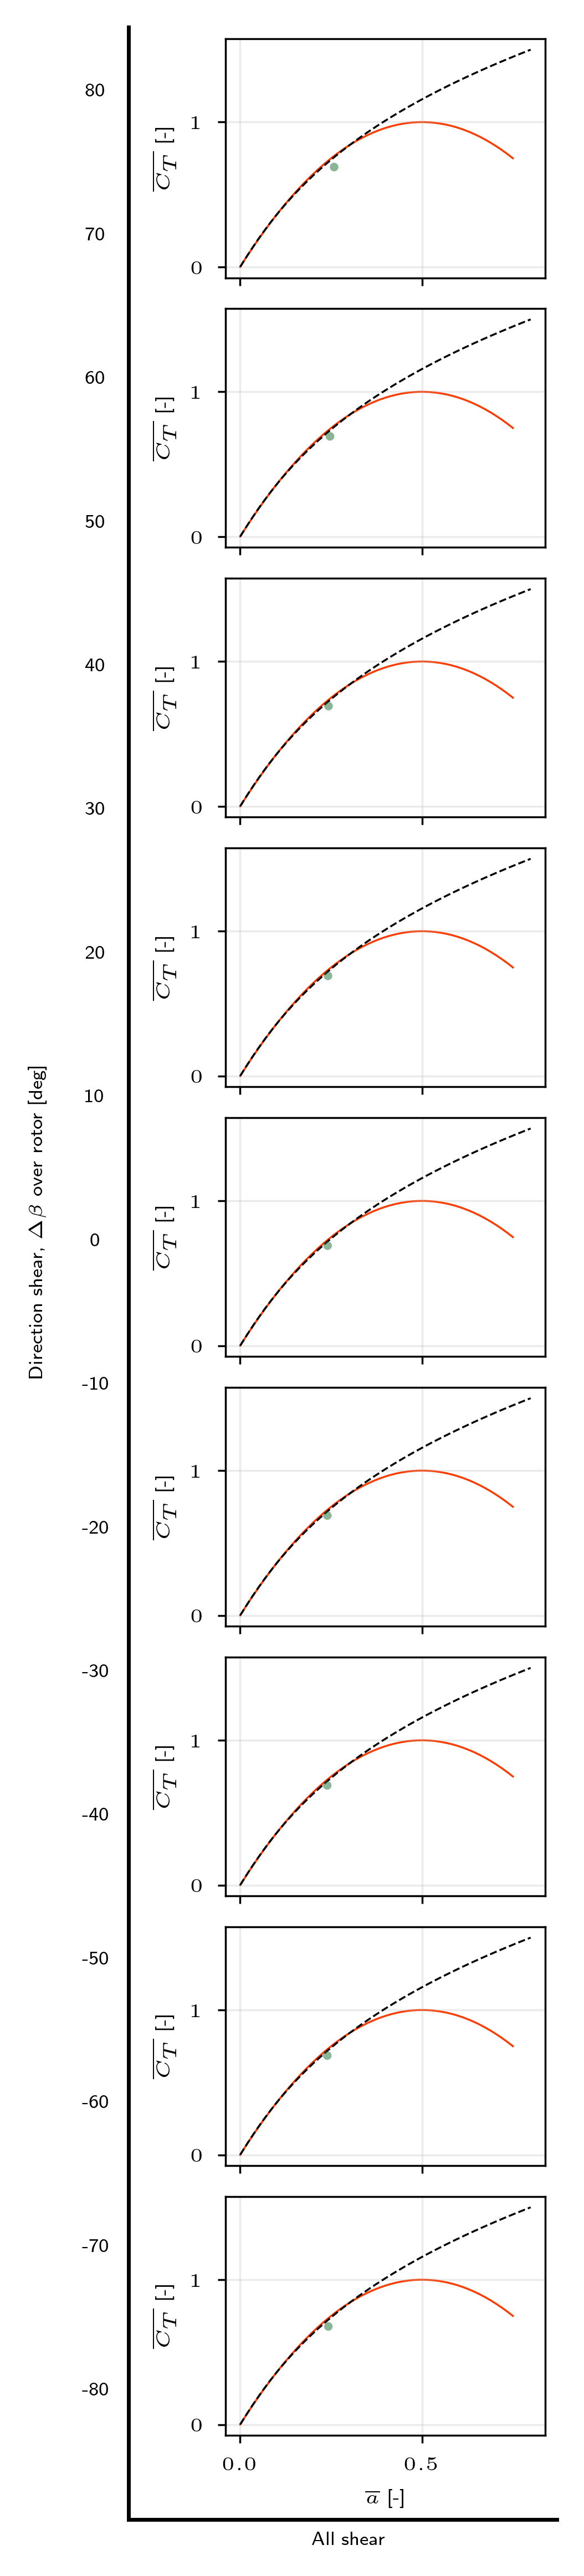

In [25]:
# Plot rotor

x_temp_vert = [0,0,0,0,0,0,0]
y_temp = [8,7,6,5,4,3,2,1,0]
coords = [pair for pair in product(x_temp_vert, y_temp)]

fig, ax = plt.subplots(nrows=9, ncols=1, figsize=(1.5, 9), constrained_layout=True,sharex=True, sharey=True)

for count,case in enumerate(casenames):

    a_mom = np.linspace(0,0.75,50)
    ct_mom = 4 * a_mom * (1 - a_mom)
    ax[coords[count][1]].plot(a_mom, ct_mom, '#ff3c00',linewidth=0.5,zorder=1)

    ct_mad = np.linspace(0,1.5,75)
    k1 = 0.2460
    k2 = 0.0586
    k3 = 0.0883
    a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad
    ax[coords[count][1]].plot(a_mad, ct_mad, 'k--',linewidth=0.5,zorder=2)

    mesh = ax[coords[count][1]].scatter(wrf_ind[count], wrf_cot[count], cmap='viridis', s=5, edgecolor='none',color='#176d2e',alpha=0.5,zorder=3)

    # ax[coords[count][1]].set_xlim([0.24,0.315])
    # ax[coords[count][1]].set_ylim([0.73,0.80])

    for label in ax[coords[count][1]].get_xticklabels():
        label.set_fontsize(5)
    for label in ax[coords[count][1]].get_yticklabels():
        label.set_fontsize(5)
    for spine in ax[coords[count][1]].spines.values():
        spine.set_linewidth(0.5)

    ax[coords[count][1]].tick_params(width=0.5, length=2)

    ax[coords[count][1]].grid(True, alpha=0.25, linewidth=0.5)

    ax[coords[count][1]].set_yticklabels(ax[coords[count][1]].get_yticklabels())

    ax[coords[count][1]].set_ylabel('$\overline{C_T}$ [-]', fontsize = 5)

ax[-1].set_xlabel('$\overline{a}$ [-]', fontsize = 5)

line_y = 0.0  # Y-position for the line (below the subplots)
line_x_start, line_x_end = -0.03, 1  # Start and end positions of the line (normalized coordinates)

# # Draw the line
fig.lines.extend([
    plt.Line2D([line_x_start, line_x_end], [line_y, line_y], color="black", transform=fig.transFigure, linewidth=1)
])

# # Add text to the number line
# positions = np.linspace(line_x_start, line_x_end, 8)+0.095  # Adjust the number of points and spacing
# labels = ['-6.0', '-4.0', '-2.0', '0.0', '2.0', '4.0', '6.0']  # Example labels

line_x = -0.03  # Y-position for the line (below the subplots)
line_y_start, line_y_end = 0.0, 1  # Start and end positions of the line (normalized coordinates)

# # Draw the line
fig.lines.extend([
    plt.Line2D([line_x, line_x], [line_y_start, line_y_end], color="black", transform=fig.transFigure, linewidth=1)
])

# # Add text to the number line
positions = np.linspace(0.05,1.03, 18)  # Adjust the number of points and spacing
labels = ['-80', '-70', '-60', '-50', '-40', '-30', '-20', '-10', '0', '10', '20', '30', '40', '50', '60', '70', '80']  # Example labels

for pos, label in zip(positions, labels):
    fig.text(line_x-0.08,pos, label, ha='center', fontsize=5)

# # Add a title for the number line
fig.text(-0.25,0.46, 'Direction shear, $\Delta \\beta$ over rotor [deg]', ha='center', fontsize=5,rotation=90)
fig.text(0.5,-0.01, 'All shear', ha='center', fontsize=5)

plt.savefig(f"./figure.png", bbox_inches="tight", dpi=600)

plt.show()

In [26]:
wrfles_bem[0]['hub_radius']

array(2.4)

In [18]:
wrfles_bem[0]['hub_diameter']/2

np.float64(2.4)

In [17]:
wrfles_bem[0].keys()

dict_keys(['diameter', 'radius', 'hub_diameter', 'hub_radius', 'hub_height', 'rOverR', 'dx', 'dy', 'dz', 'dt', 'Nx', 'Ny', 'Nz', 'tower_xloc', 'tower_yloc', 'Nsct', 'Nelm', 'uinf', 'omega', 'thrust', 'power_aero', 'power_mech', 'power_gen', 'torque_aero', 'ct', 'cp', 'v0', 'f', 'fn', 'ft', 'l', 'd', 'cl', 'cd', 'aoa', 'v1', 'u', 'v', 'w', 'v_tan', 'vrel', 'phi', 'bpx', 'bpy', 'bpz', 'shapiroM'])

In [17]:
np.mean(wrfles_bem[count]['thrust'], axis=0)

array([714794.2], dtype=float32)

In [22]:
np.mean(wrfles_bem[count]['thrust'], axis=0)

array([714829.8], dtype=float32)

In [35]:
colors = sns.dark_palette("#69d", 4)

In [34]:
sns.dark_palette("#69d", 4)[::-1]

[(np.float64(0.4), np.float64(0.6), np.float64(0.8666666666666667)),
 (np.float64(0.3137166044882655),
  np.float64(0.4493648793461167),
  np.float64(0.6318257175920923)),
 (np.float64(0.227433208976531),
  np.float64(0.2987297586922334),
  np.float64(0.39698476851751796)),
 (np.float64(0.1411498134647965),
  np.float64(0.14809463803835013),
  np.float64(0.1621438194429436))]

In [36]:
colors_v = colors[::-1] + colors[1::]

In [ ]:
purp = sns.cubehelix_palette(9)

In [39]:
styles = [r'-.',r'-.',r'-.',r'-',r'--',r'--',r'--']

Text(0.5, 0, '$U/U_{\\infty}$ [-]')

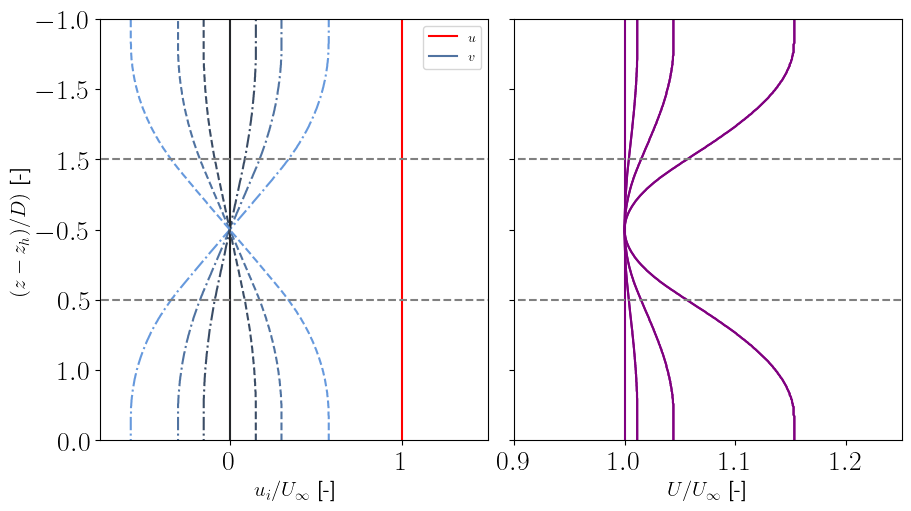

In [67]:
fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(9, 5), constrained_layout=True, sharey=True)

subset_indices = np.array([55, 57, 58, 59, 60, 61, 63])

fontsize = 15

for i in range(len(subset_indices)):
    ax[0].plot(profiles[:,subset_indices[i]]/7,full_z,color=colors_v[i],linestyle=styles[i])

ax[0].plot(profiles_u[:,subset_indices[0]]/7,full_z,color='r',linestyle='-')

ax[0].plot([-10,-10],[1,1],color='r',linestyle='-',label='$u$')
ax[0].plot([-10,-10],[1,1],color=colors_v[5],linestyle='-',label='$v$')

for i in range(len(subset_indices)):
    ax[1].plot(np.sqrt(profiles[:,subset_indices[i]]**2 + profiles_u[:,subset_indices[i]]**2)/7,full_z,color='purple',linestyle='-')

ax[0].plot([-1,4],[477.5,477.5], '--', color = 'grey')
ax[0].plot([-1,4],[278.5,278.5], '--', color = 'grey')

ax[1].plot([-1,4],[477.5,477.5], '--', color = 'grey')
ax[1].plot([-1,4],[278.5,278.5], '--', color = 'grey')

ax[0].set_ylim([79.5,676.5])
ax[0].set_xlim([-0.75,1.5])
ax[1].set_xlim([0.9,1.25])

ax[0].legend()

vec = ticks = np.array([79.5, 179,278.5,378,477.5,577,676.5])

ax[0].set_yticks(vec)
ax[0].set_yticklabels({'$-1.5$','$-1.0$','$-0.5$','$0.0$','$0.5$','$1.0$','$1.5$'})

ax[0].set_ylabel('$(z-z_h)/D)$ [-]',fontsize=fontsize)
ax[0].set_xlabel('$u_i/U_{\infty}$ [-]',fontsize=fontsize)
ax[1].set_xlabel('$U/U_{\infty}$ [-]',fontsize=fontsize)


